In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
#simpeg Imports -- For forward problem
# SimPEG functionality
from simpeg.potential_fields import magnetics
from simpeg.utils import plot2Ddata, model_builder, download
from simpeg import maps

# discretize functionality
from discretize import TensorMesh
from discretize.utils import mkvc, active_from_xyz

# Common Python functionality
import numpy as np
from scipy.interpolate import LinearNDInterpolator
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
import tarfile
from pathlib import Path

mpl.rcParams.update({"font.size": 14}) #(No Idea..)

#Simpeg imports -- Not for forward problem
from simpeg import (
    maps,
    data,
    data_misfit,
    inverse_problem,
    regularization,
    optimization,
    directives,
    inversion,
)

import sys
sys.path.append("../src")

import init_utils


save_output = False  # Optional, (No Idea..)

#Fix path to data directory
NOTEBOOK_DIR = Path().resolve()
DATA_DIR = NOTEBOOK_DIR.parent / "data" / "raw"

 ### Read in data
We have four data files:
- obs.mag
- sus.mod
- sus.msh
- topo.dat

obs.mag is five columns organized as the following (containing total field oberservations):

X       Y       Z       DATA_VALUE    ERROR

sus.mod is one column of susceptibiity values

sus.msh decribes the tensor mesh

topo.dat is three columns, describing the topography as such:

X       Y       Z  

In [4]:
#Load data
observations = init_utils.read_obs_mag("obs.mag")
mesh_data = init_utils.read_tensor_mesh(DATA_DIR / "sus.msh")
upward_data = init_utils.load_cache("upward_data")

dobs_upward_continued = upward_data["dobs"]
errors = upward_data["errors"]


#Load topography and active cells
topo_and_active_cells = init_utils.load_cache("Topo_and_active")

topography = topo_and_active_cells["topography"]
active_cells = topo_and_active_cells["active_cells"]

#Load survey info
Surver_info = init_utils.load_cache("survey_info")

receiver_locations_good = Surver_info["receivers"]
receiver_list = magnetics.receivers.Point(receiver_locations_good, components=['tmi']) #List of receivers from locations
receiver_list = [receiver_list]
amplitude = Surver_info["amplitude"]
inclination = Surver_info["inclination"]
declination = Surver_info["declination"]


### Plot Topography

[saved] /Users/jackson/projects/EOSC-454-Project-2026/outputs/figures/topography.png


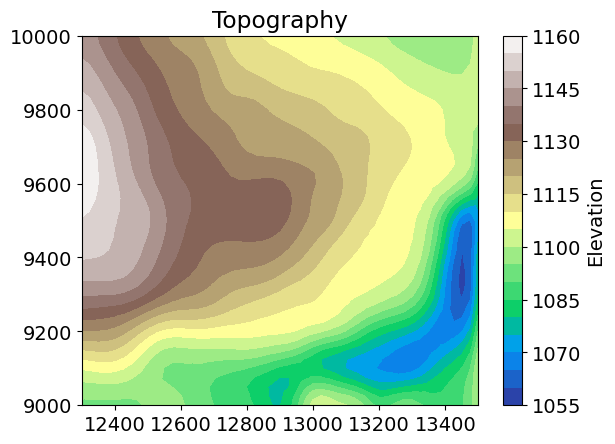

In [5]:
x_topo = topography[:, 0]
y_topo = topography[:, 1]
z_topo = topography[:, 2]

plt.tricontourf(x_topo, y_topo, z_topo, levels=20, cmap="terrain")
plt.colorbar(label="Elevation")
# plt.scatter(x_topo, y_topo, c="k", s=1)

plt.title("Topography")
init_utils.save_figure('topography')
plt.show()


### Create tensor mesh

In [6]:
nx, ny, nz = mesh_data["nx"], mesh_data["ny"], mesh_data["nz"]
dx, dy, dz = mesh_data["dx"], mesh_data["dy"], mesh_data["dz"]
x0, y0, z0 = mesh_data["x0"], mesh_data["y0"], mesh_data["z0"]

x_mesh = [(dx, 5, -1.3), (dx, nx), (dx, 5, 1.3)] 
y_mesh = [(dy, 5, -1.3), (dy, ny), (dy, 5, 1.3)]
z_mesh = [(dz, 5, -1.3), (dz, nz)]

tensor_mesh = TensorMesh([x_mesh, y_mesh, z_mesh], "CCN")

hx, hy, hz = tensor_mesh.h

tensor_mesh.origin = np.r_[
    x0 - np.sum(hx[:5]),
    y0 - np.sum(hy[:5]),
    z0 - np.sum(hz),
]

### Create Model Map

In [7]:
n_active = int(active_cells.sum())
model_map = maps.IdentityMap(nP=n_active) #simpeg identity map

### Plot mesh with active cells

[saved] /Users/jackson/projects/EOSC-454-Project-2026/outputs/figures/Mesh_with_active_cells.png


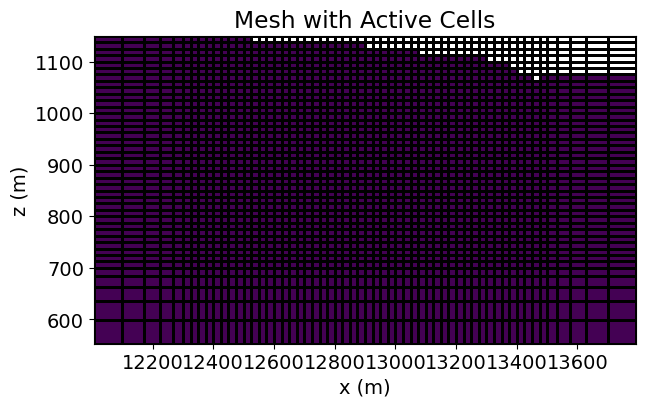

In [8]:
fig = plt.figure(figsize=(7, 4))
ax = fig.add_subplot(111)

active_plot = maps.InjectActiveCells(tensor_mesh, active_cells, np.nan)

tensor_mesh.plot_slice(
    active_plot * np.ones(n_active),
    normal="Y",
    ind=int(tensor_mesh.shape_cells[1] / 2),
    ax=ax,
    grid=True,
    pcolor_opts={"cmap": "viridis"},
)

ax.set_title("Mesh with Active Cells")
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")

init_utils.save_figure('Mesh_with_active_cells')

 ### Define Survey 

In [9]:
up_receiver_list = magnetics.receivers.Point(receiver_locations_good, components=["tmi"])
up_source_field = magnetics.sources.UniformBackgroundField(
    receiver_list=[up_receiver_list],
    amplitude=amplitude, inclination=inclination, declination=declination
)
up_survey = magnetics.survey.Survey(up_source_field)

up_sim = magnetics.simulation.Simulation3DIntegral(
    survey=up_survey, mesh=tensor_mesh, chiMap=model_map, 
    active_cells=active_cells, model_type="scalar"
)


 ### Visualize data 

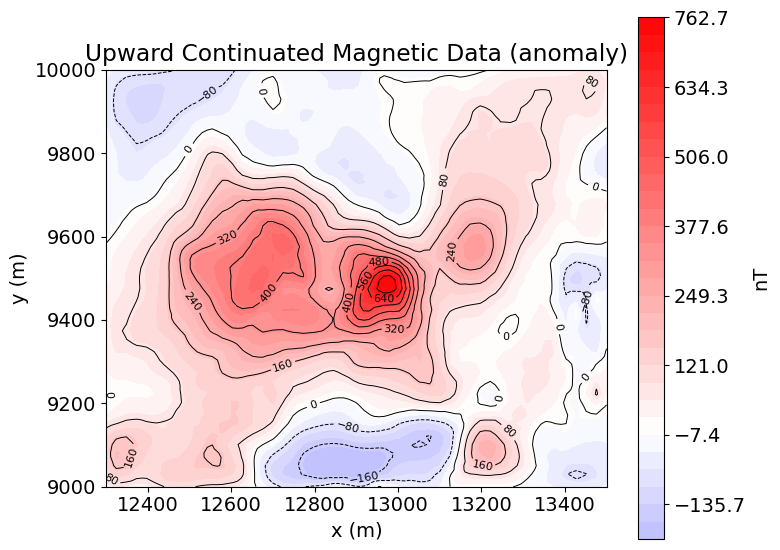

In [10]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

# Symmetric color scale
vmax = np.max(np.abs(dobs_upward_continued))
norm = mpl.colors.Normalize(vmin=-vmax, vmax=vmax)

# --- Filled contours (SimPEG) ---
cplot = plot2Ddata(
    receiver_locations_good[:, :2],
    dobs_upward_continued,
    ax=ax,
    ncontour=30,
    contourOpts={"cmap": "bwr", "norm": norm},
)

# --- Interpolate to grid for contour lines ---
from scipy.interpolate import griddata

x = receiver_locations_good[:, 0]
y = receiver_locations_good[:, 1]

xi = np.linspace(x.min(), x.max(), 100)
yi = np.linspace(y.min(), y.max(), 100)
Xi, Yi = np.meshgrid(xi, yi)

Zi = griddata((x, y), dobs_upward_continued, (Xi, Yi), method="linear")

# --- Solid contour lines ---
cs = ax.contour(
    Xi, Yi, Zi,
    levels=15,
    colors="k",
    linewidths=0.7
)

# Optional: label contours
ax.clabel(cs, inline=True, fontsize=8)

# Titles and labels
ax.set_title("Upward Continuated Magnetic Data (anomaly)")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")

# Colorbar
cbar = plt.colorbar(cplot[0], ax=ax)
cbar.set_label("nT")

plt.tight_layout()
plt.show()

 ### Define simulation and data object for upward continue data 

In [11]:
simulation = magnetics.simulation.Simulation3DIntegral(
    survey=up_survey,
    mesh=tensor_mesh,
    model_type="scalar",
    chiMap=model_map,
    active_cells=active_cells,
    store_sensitivities="forward_only",
    engine="choclo",
)

data_object = data.Data(up_survey, dobs=dobs_upward_continued, standard_deviation=errors)

 ### Define starting and reference models 

In [12]:

starting_tensor_model = 1e-4 * np.ones(n_active)
reference_model = np.zeros_like(starting_tensor_model)

# Mapping to ignore inactive cells when plotting
tensor_plotting_map = maps.InjectActiveCells(tensor_mesh, active_cells, np.nan)

 ### Define Regularization 

In [13]:
#Using weighted least squares regularization to costrain the regularization result
regularization_tensor = regularization.WeightedLeastSquares(
    tensor_mesh,
    active_cells=active_cells,
    length_scale_x=dx,
    length_scale_y=dy,
    length_scale_z=dz,
    reference_model= reference_model,
    reference_model_in_smooth=False, #Maybe change to true? check results first
)

 ### Define Data Misfit 

In [14]:
# Using L2 norm of the weighted residual between the observed and predicted data for a given model
data_misfit_tensor_L2 = data_misfit.L2DataMisfit(data=data_object, simulation=simulation)

 ### Define Optimization 

In [15]:
optimization_tensor = optimization.ProjectedGNCG(
    maxIter=100, lower=0.0, maxIterLS=20, cg_maxiter=10, cg_rtol=1e-2
)

 ### Define the inverse Problem 

In [16]:
# Full inverse problem definition needs daata misfit, regularization, and optimization objects
inverse_problem_L2 = inverse_problem.BaseInvProblem(data_misfit_tensor_L2, regularization_tensor, optimization_tensor)

 ### Provide the inversion directives 

In [17]:
sensitivity_weights = directives.UpdateSensitivityWeights(every_iteration=False)
update_jacobi = directives.UpdatePreconditioner(update_every_iteration=True)
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=10)
beta_schedule = directives.BetaSchedule(coolingFactor=2.0, coolingRate=1)
target_misfit = directives.TargetMisfit(chifact=1.0)

directives_list = [
    sensitivity_weights,
    update_jacobi,
    starting_beta,
    beta_schedule,
    target_misfit,
]

 ### Define and run Inversion 

In [18]:
# # Here we combine the inverse problem and the set of directives
# inv_L2 = inversion.BaseInversion(inverse_problem_L2, directives_list)

# # Run inversion
# recovered_tensor_model = inv_L2.run(starting_tensor_model)

# init_utils.save_model("l2", recovered_tensor_model)

### Load l2 model 
if dont want to run inversion (~5 minutes)

In [19]:
recovered_tensor_model = init_utils.load_model("l2")

 ### Plot Misfit 

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


dpred stats: -206.73184807339035 625.9409113998471 [-206.73184807 -198.91019458 -197.94771059 -196.56558848 -193.05153665
 -188.60374121 -181.77259832 -180.29008003 -175.38067514 -174.80738668]
misfit stats: -72.3802155932258 176.05648907483157
[saved] /Users/jackson/projects/EOSC-454-Project-2026/outputs/figures/l2_misfit.png


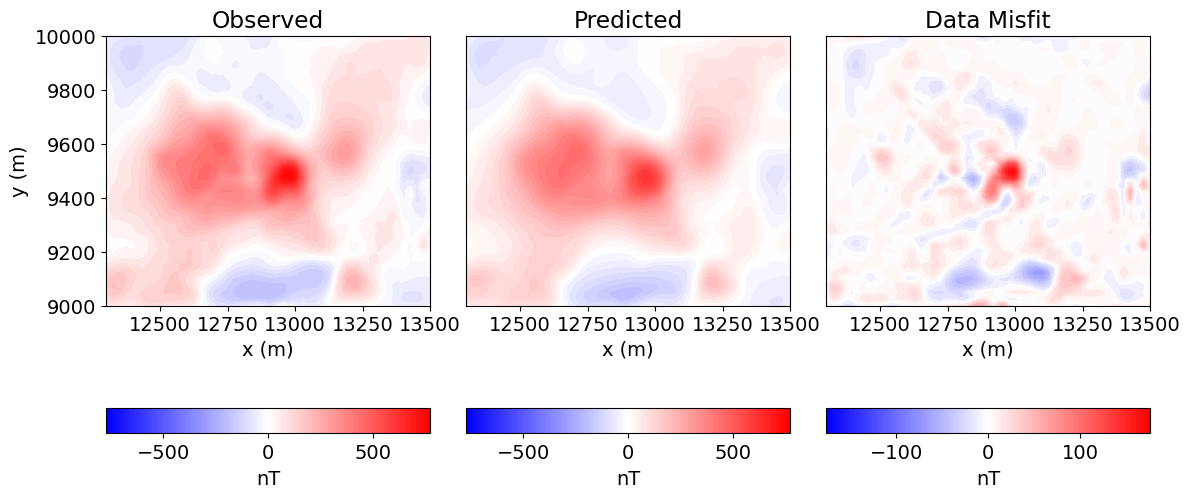

In [20]:
# Predicted data with final recovered model.
dpred_L2 = simulation.dpred(recovered_tensor_model)

# Observed data | Predicted data | Data misfit
data_array = np.c_[dobs_upward_continued, dpred_L2, (dobs_upward_continued - dpred_L2)]

print("dpred stats:", np.nanmin(dpred_L2), np.nanmax(dpred_L2), np.unique(dpred_L2)[:10])
print("misfit stats:", np.nanmin(dobs_upward_continued - dpred_L2), np.nanmax(dobs_upward_continued - dpred_L2))

fig = plt.figure(figsize=(12, 5))
plot_title = ["Observed", "Predicted", "Data Misfit"]
plot_units = ["nT", "nT", "nT"]

ax1 = 3 * [None]
ax2 = 3 * [None]
norm = 3 * [None]
cbar = 3 * [None]
cplot = 3 * [None]
v_lim = [np.max(np.abs(dobs_upward_continued)), np.max(np.abs(dobs_upward_continued)), np.max(np.abs(dobs_upward_continued - dpred_L2))]

for ii in range(0, 3):
    ax1[ii] = fig.add_axes([0.3 * ii + 0.1, 0.2, 0.27, 0.75])
    norm[ii] = mpl.colors.Normalize(vmin=-v_lim[ii], vmax=v_lim[ii])
    cplot[ii] = plot2Ddata(
        receiver_list[0].locations,
        data_array[:, ii],
        ax=ax1[ii],
        ncontour=30,
        contourOpts={"cmap": "bwr", "norm": norm[ii]},
    )
    ax1[ii].set_title(plot_title[ii])
    ax1[ii].set_xlabel("x (m)")
    if ii == 0:
        ax1[ii].set_ylabel("y (m)")
    else:
        ax1[ii].set_yticks([])

    ax2[ii] = fig.add_axes([0.3 * ii + 0.1, 0.05, 0.27, 0.05])
    cbar[ii] = mpl.colorbar.ColorbarBase(
        ax2[ii], norm=norm[ii], orientation="horizontal", cmap=mpl.cm.bwr
    )
    cbar[ii].set_label(plot_units[ii], labelpad=5)

init_utils.save_figure('l2_misfit')
plt.show()


### Plot Recovered Model

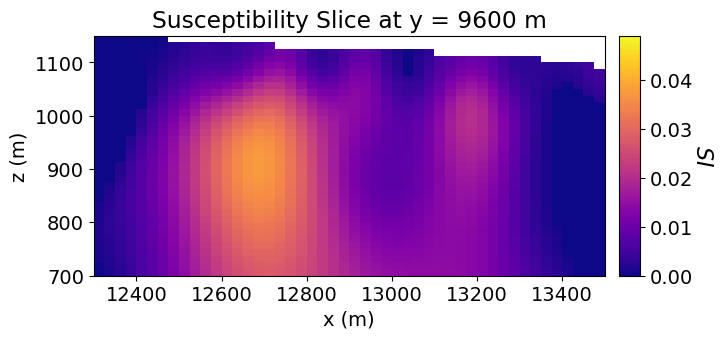

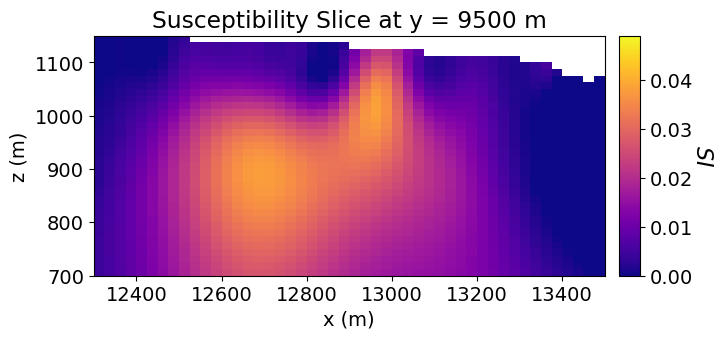

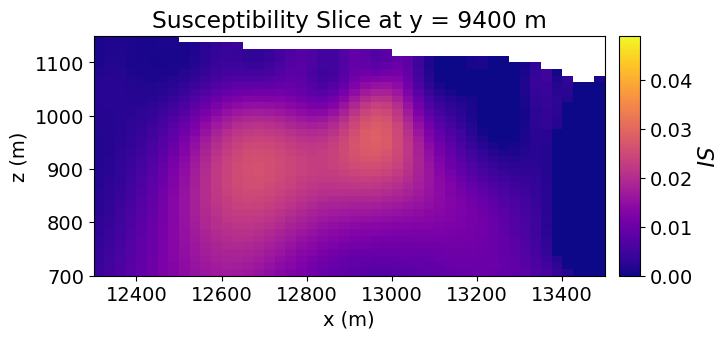

In [21]:
def y_to_index(y_value):
    return np.argmin(np.abs(tensor_mesh.cell_centers_y - y_value))

slice_ys = [9600, 9500, 9400]

full_model = tensor_plotting_map * recovered_tensor_model

for y_val in slice_ys:
    ind = y_to_index(y_val)

    fig = plt.figure(figsize=(7, 3))
    ax1 = fig.add_axes([0.1, 0.1, 0.73, 0.8])

    norm = mpl.colors.Normalize(
        vmin=np.min(recovered_tensor_model),
        vmax=np.max(recovered_tensor_model)
    )

    tensor_mesh.plot_slice(
        full_model,
        normal="Y",
        ax=ax1,
        ind=ind,
        grid=False,
        pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
    )

    ax1.set_title(f"Susceptibility Slice at y = {y_val} m")
    ax1.set_xlabel("x (m)")
    ax1.set_ylabel("z (m)")
    ax1.set_xlim([x0, x0 + nx * dx])
    ax1.set_ylim([z0 - nz * dz, z0]) 

    ax2 = fig.add_axes([0.85, 0.1, 0.03, 0.8])
    cbar = mpl.colorbar.ColorbarBase(
        ax2, norm=norm, orientation="vertical", cmap=mpl.cm.plasma
    )
    cbar.set_label("$SI$", rotation=270, labelpad=15, size=16)

    plt.show()


 ### Now use IRLS
Mesh, active cells, model map, starting and refernce models, forward simulation, misfit and optimization are the same.
Regularization, uncertainties and the inversion directions are different 

 ## Re-weight uncertainties 

In [22]:
# Compute normalized data misfits
normalized_data_misfits = (dobs_upward_continued - dpred_L2) / errors

# Generate new uncertainties
new_uncertainties = errors.copy()
new_uncertainties[np.abs(normalized_data_misfits) > 2.0] /= 2.5

# Generate new data object
new_data_object = data.Data(up_survey, dobs=dobs_upward_continued, standard_deviation=new_uncertainties)

 ### Define and run inversion  

In [23]:
# recovered_models = []
# model_names = []

# vals = [0, 0.5, 1.0]

# for smallness in vals:
#     for smoothness in vals:
        
#         #Fresh each run
#         # Using L2 norm of the weighted residual between the observed and predicted data for a given model
#         data_misfit_tensor_IRLS = data_misfit.L2DataMisfit(data=new_data_object, simulation=simulation)

#         # Equal emphasis on smallness and smoothness is applied by using the inverse square of the smallest cell dimension.
#         regularization_irls_tensor = regularization.Sparse(
#         tensor_mesh,
#         active_cells=active_cells,
#         alpha_s= dz**-2,
#         alpha_x=1,
#         alpha_y=1,
#         alpha_z=1,
#         reference_model=reference_model,
#         reference_model_in_smooth=False,
#         norms=[smallness, smoothness, smoothness, smoothness],
#         )   

#         #optimization remains the same
#         optimization_tensor = optimization.ProjectedGNCG(
#         maxIter=100, lower=0.0, maxIterLS=20, cg_maxiter=10, cg_rtol=1e-2
#         )

#         #Provide Inversion Directives
#         sensitivity_weights_irls = directives.UpdateSensitivityWeights(every_iteration=False)
#         starting_beta_irls = directives.BetaEstimate_ByEig(beta0_ratio=10)
#         update_jacobi_irls = directives.UpdatePreconditioner(update_every_iteration=True)
#         update_irls = directives.UpdateIRLS(
#             cooling_factor=2,
#             f_min_change=1e-4,
#             max_irls_iterations=25,
#             chifact_start=1.0,
#         )

#         directives_list_irls = [
#             update_irls,
#             sensitivity_weights_irls,
#             starting_beta_irls,
#             update_jacobi_irls,
#         ]
        
#         #Define Inverse Problem
#         inv_prob_irls = inverse_problem.BaseInvProblem(data_misfit_tensor_IRLS, regularization_irls_tensor, optimization_tensor)

#         # Here we combine the inverse problem and the set of directives
#         # Run inversion
#         inv_irls = inversion.BaseInversion(inv_prob_irls, directives_list_irls)
#         recovered_tensor_irls_model = inv_irls.run(starting_tensor_model)

#         # Cache Model
#         model_name = f"IRLS_s{smallness}_sm{smoothness}".replace(".", "")
#         init_utils.save_model(model_name, recovered_tensor_irls_model)

#         recovered_models.append(recovered_tensor_irls_model)
#         model_names.append(model_name)

### Load Models
If dont want to run inversion (hours)

In [24]:
IRLS_s0_sm0 = init_utils.load_model("IRLS_s0_sm0")
IRLS_s0_sm05 = init_utils.load_model("IRLS_s0_sm05")
IRLS_s0_sm10 = init_utils.load_model("IRLS_s0_sm10")
IRLS_s05_sm0 = init_utils.load_model("IRLS_s05_sm0")
IRLS_s05_sm05 = init_utils.load_model("IRLS_s05_sm05")
IRLS_s05_sm10 = init_utils.load_model("IRLS_s05_sm10")
IRLS_s10_sm0 = init_utils.load_model("IRLS_s10_sm0")
IRLS_s10_sm05 = init_utils.load_model("IRLS_s10_sm05")
IRLS_s10_sm10 = init_utils.load_model("IRLS_s10_sm10")

recovered_models = [
    IRLS_s0_sm0, IRLS_s0_sm05, IRLS_s0_sm10,
    IRLS_s05_sm0, IRLS_s05_sm05, IRLS_s05_sm10,
    IRLS_s10_sm0, IRLS_s10_sm05, IRLS_s10_sm10
]

 ### Plot Different models

/var/folders/3d/yf36xnp966v6l9x5ngg5879w0000gn/T/ipykernel_14844/559457167.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


[saved] /Users/jackson/projects/EOSC-454-Project-2026/outputs/figures/IRLS_9slices.png


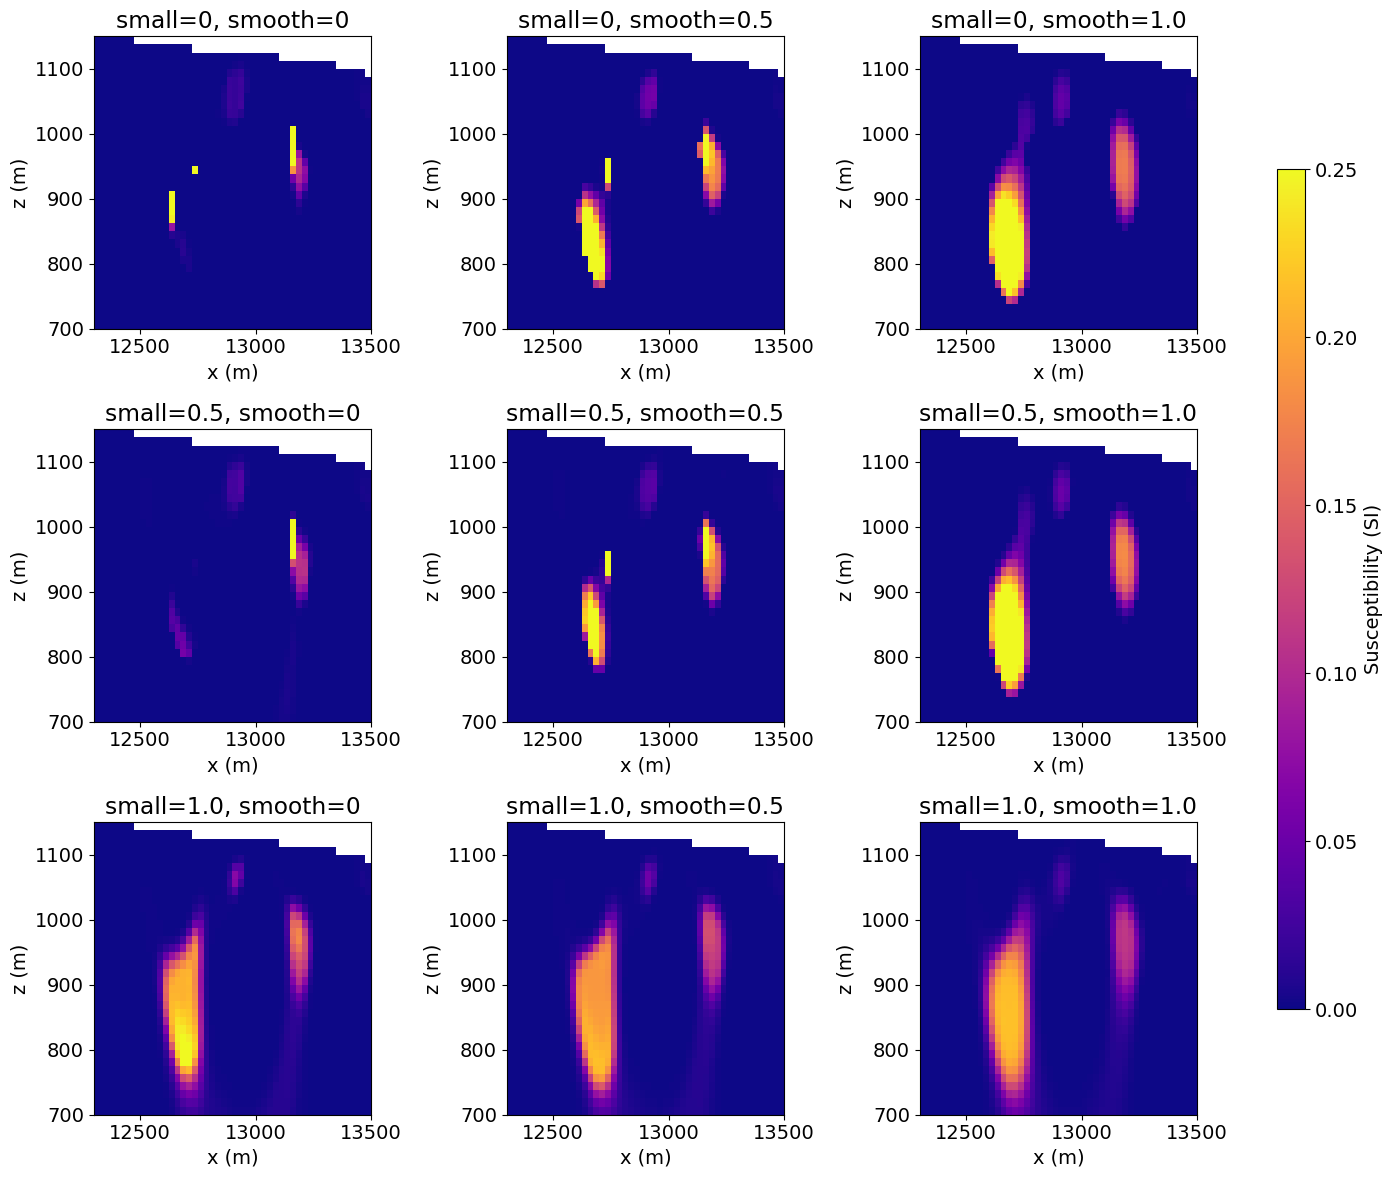

In [25]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Target slice
y_val = 9600

def y_to_index(y_value):
    return np.argmin(np.abs(tensor_mesh.cell_centers_y - y_value))

ind = y_to_index(y_val)

# Expand all models to full mesh (like your working code)
full_models = [tensor_plotting_map * m for m in recovered_models]

# Shared color scale across ALL 9 models

vmin = 0
vmax = 0.25
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(3, 3, figsize=(14, 12))

vals = [0, 0.5, 1.0]

k = 0
for i, smallness in enumerate(vals):
    for j, smoothness in enumerate(vals):

        ax = axes[i, j]
        model_full = full_models[k]
        k += 1

        tensor_mesh.plot_slice(
            model_full,
            normal="Y",
            ind=ind,
            ax=ax,
            grid=False,
            pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
        )

        ax.set_title(f"small={smallness}, smooth={smoothness}")
        ax.set_xlabel("x (m)")
        ax.set_ylabel("z (m)")
        ax.set_xlim([x0, x0 + nx * dx])
        ax.set_ylim([z0 - nz * dz, z0])

# ---- ONE shared colorbar (like your working version) ----
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
mpl.colorbar.ColorbarBase(
    cbar_ax,
    norm=norm,
    cmap=mpl.cm.plasma,
).set_label("Susceptibility (SI)")

plt.tight_layout(rect=[0, 0, 0.9, 1])
init_utils.save_figure('IRLS_9slices')
plt.show()


### Plot Misfit for all IRLS Models

/var/folders/3d/yf36xnp966v6l9x5ngg5879w0000gn/T/ipykernel_14844/1461236599.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


[saved] /Users/jackson/projects/EOSC-454-Project-2026/outputs/figures/IRLS_9_misfits.png


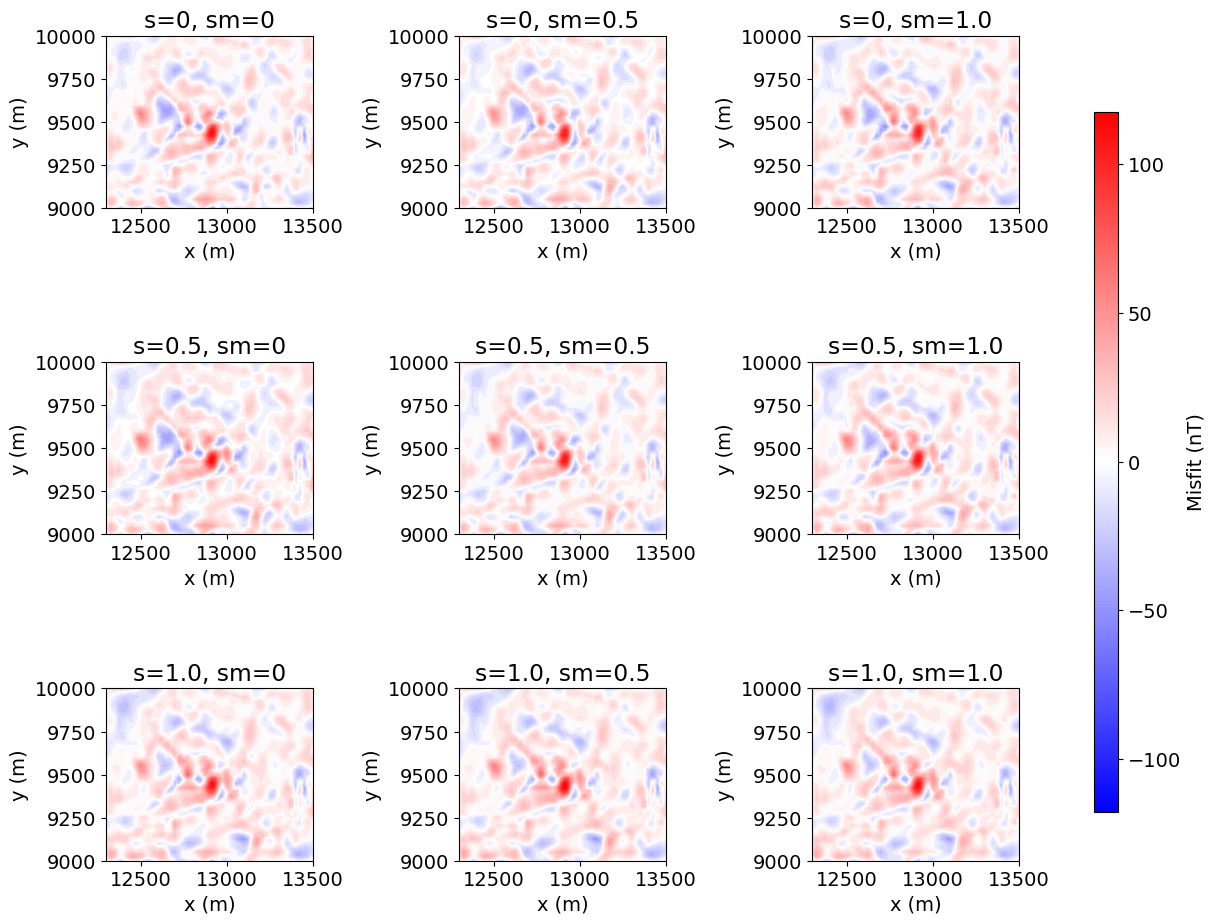

In [26]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

vals = [0, 0.5, 1.0]

# store all misfits first to get consistent color scale
misfits = []

for m in recovered_models:
    dpred = simulation.dpred(m)
    misfit = dobs_upward_continued - dpred
    misfits.append(misfit)

# global symmetric color scale
all_vals = np.hstack(misfits)
vlim = np.max(np.abs(all_vals))

k = 0
for i, smallness in enumerate(vals):
    for j, smoothness in enumerate(vals):

        ax = axes[i, j]

        misfit = misfits[k]
        k += 1

        norm = mpl.colors.Normalize(vmin=-vlim, vmax=vlim)

        plot2Ddata(
            receiver_list[0].locations,
            misfit,
            ax=ax,
            ncontour=30,
            contourOpts={"cmap": "bwr", "norm": norm},
        )

        ax.set_title(f"s={smallness}, sm={smoothness}")
        ax.set_xlabel("x (m)")
        ax.set_ylabel("y (m)")

# ONE shared colorbar  
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
mpl.colorbar.ColorbarBase(
    cbar_ax,
    norm=mpl.colors.Normalize(vmin=-vlim, vmax=vlim),
    cmap=mpl.cm.bwr,
).set_label("Misfit (nT)")

plt.tight_layout(rect=[0, 0, 0.9, 1])
init_utils.save_figure('IRLS_9_misfits')
plt.show()


 ### Plot all models 

In [27]:
# slice_ys = [9600, 9500, 9400]

# def y_to_index(y_value):
#     return np.argmin(np.abs(tensor_mesh.cell_centers_y - y_value))

# # Expand models to full mesh (with NaNs in air)
# l2_full = tensor_plotting_map * recovered_tensor_model
# irls_full = tensor_plotting_map * recovered_tensor_irls_model

# fig, axes = plt.subplots(len(slice_ys), 2, figsize=(10, 9))

# for i, y_val in enumerate(slice_ys):
#     ind = y_to_index(y_val)

#     # Shared color scale for fair comparison
#     vmin = min(
#         np.nanmin(l2_full), np.nanmin(irls_full)
#     )
#     vmax = max(
#         np.nanmax(l2_full), np.nanmax(irls_full)
#     )
#     norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

#     # --- L2 ---
#     ax = axes[i, 0]
#     tensor_mesh.plot_slice(
#         l2_full,
#         normal="Y",
#         ind=ind,
#         ax=ax,
#         grid=False,
#         pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
#     )
#     ax.set_title(f"L2 | y = {y_val} m")
#     ax.set_xlabel("x (m)")
#     ax.set_ylabel("z (m)")
#     ax.set_xlim([x0, x0 + nx * dx])
#     ax.set_ylim([z0 - nz * dz, z0])

#     # --- IRLS ---
#     ax = axes[i, 1]
#     tensor_mesh.plot_slice(
#         irls_full,
#         normal="Y",
#         ind=ind,
#         ax=ax,
#         grid=False,
#         pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
#     )
#     ax.set_title(f"IRLS | y = {y_val} m")
#     ax.set_xlabel("x (m)")
#     ax.set_ylabel("z (m)")
#     ax.set_xlim([x0, x0 + nx * dx])
#     ax.set_ylim([z0 - nz * dz, z0]) 

# # Add ONE shared colorbar
# cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
# mpl.colorbar.ColorbarBase(
#     cbar_ax,
#     norm=norm,
#     cmap=mpl.cm.plasma,
# ).set_label("Susceptibility (SI)")

# plt.tight_layout(rect=[0, 0, 0.9, 1])
# plt.show()

In [28]:
# from scipy.interpolate import griddata

# def get_slice_data(model, ind):
#     # extract cell centers in the slice plane
#     x = tensor_mesh.cell_centers_x
#     z = tensor_mesh.cell_centers_z

#     X, Z = np.meshgrid(x, z, indexing="xy")

#     # grab values at this Y slice
#     y_target = tensor_mesh.cell_centers_y[ind]
#     points = np.c_[
#         tensor_mesh.gridCC[:, 0],
#         tensor_mesh.gridCC[:, 1],
#         tensor_mesh.gridCC[:, 2],
#     ]

#     values = model

#     # filter slice points
#     mask = np.abs(points[:, 1] - y_target) < tensor_mesh.h[1].min()

#     xi = points[mask][:, 0]
#     zi = points[mask][:, 2]
#     vi = values[mask]

#     V = griddata((xi, zi), vi, (X, Z), method="linear")

#     return X, Z, V

In [29]:
# X, Z, V = get_slice_data(l2_full, ind)


# slice_ys = [9600, 9500, 9400]

# def y_to_index(y_value):
#     return np.argmin(np.abs(tensor_mesh.cell_centers_y - y_value))

# # Expand models to full mesh (with NaNs in air)
# l2_full = tensor_plotting_map * recovered_tensor_model
# irls_full = tensor_plotting_map * recovered_tensor_irls_model

# fig, axes = plt.subplots(len(slice_ys), 2, figsize=(10, 9))

# for i, y_val in enumerate(slice_ys):
#     ind = y_to_index(y_val)

#     # Shared color scale for fair comparison
#     vmin = min(
#         np.nanmin(l2_full), np.nanmin(irls_full)
#     )
#     vmax = max(
#         np.nanmax(l2_full), np.nanmax(irls_full)
#     )
#     norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

#     # --- L2 ---
#     ax = axes[i, 0]
#     tensor_mesh.plot_slice(
#         l2_full,
#         normal="Y",
#         ind=ind,
#         ax=ax,
#         grid=False,
#         pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
#     )
#     ax.set_title(f"L2 | y = {y_val} m")
#     ax.set_xlabel("x (m)")
#     ax.set_ylabel("Depth (m)")
#     ax.invert_yaxis()
#     ax.set_xlim([x0, x0 + nx * dx])
#     ax.set_ylim([z0 - nz * dz, z0])
#     ax.contour(
#     X,
#     Z,
#     V,
#     levels=8,
#     colors="black",
#     linewidths=0.6,
#     alpha=0.6,
# )

#     # --- IRLS ---
#     ax = axes[i, 1]
#     tensor_mesh.plot_slice(
#         irls_full,
#         normal="Y",
#         ind=ind,
#         ax=ax,
#         grid=False,
#         pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
#     )
#     ax.set_title(f"IRLS | y = {y_val} m")
#     ax.set_xlabel("x (m)")
#     ax.set_ylabel("Depth (m)")
#     ax.invert_yaxis()
#     ax.set_xlim([x0, x0 + nx * dx])
#     ax.set_ylim([z0 - nz * dz, z0]) 
#     ax.contour(
#     X,
#     Z,
#     V,
#     levels=8,
#     colors="black",
#     linewidths=0.6,
#     alpha=0.6,
# )

# # Add ONE shared colorbar
# cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
# mpl.colorbar.ColorbarBase(
#     cbar_ax,
#     norm=norm,
#     cmap=mpl.cm.plasma,
# ).set_label("Susceptibility (SI)")

# plt.tight_layout(rect=[0, 0, 0.9, 1])
# plt.show()


 # Use sus.mod to compare results 

In [30]:
# Load chosen Models
IRLS_chosen = init_utils.load_model("IRLS_s10_sm10")
L2_chosen = init_utils.load_model("l2")

mesh_ubc = TensorMesh.read_UBC(DATA_DIR / "sus.msh")
model_ubc = mesh_ubc.read_model_UBC(DATA_DIR / "sus.mod")

In [31]:
points = mesh_ubc.gridCC
values = model_ubc

from scipy.spatial import cKDTree

tree = cKDTree(mesh_ubc.gridCC)
_, inds = tree.query(tensor_mesh.gridCC)

interp_model = model_ubc[inds]

true_active = interp_model[active_cells]
true_full = tensor_plotting_map * true_active

In [32]:
l2_full   = tensor_plotting_map * L2_chosen
irls_full = tensor_plotting_map * IRLS_chosen

In [33]:
def y_to_index(y_value):
    return np.argmin(np.abs(tensor_mesh.cell_centers_y - y_value))

/var/folders/3d/yf36xnp966v6l9x5ngg5879w0000gn/T/ipykernel_14844/3844257839.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


[saved] /Users/jackson/projects/EOSC-454-Project-2026/outputs/figures/IRLSs10_sm10_l2_true_comparison.png


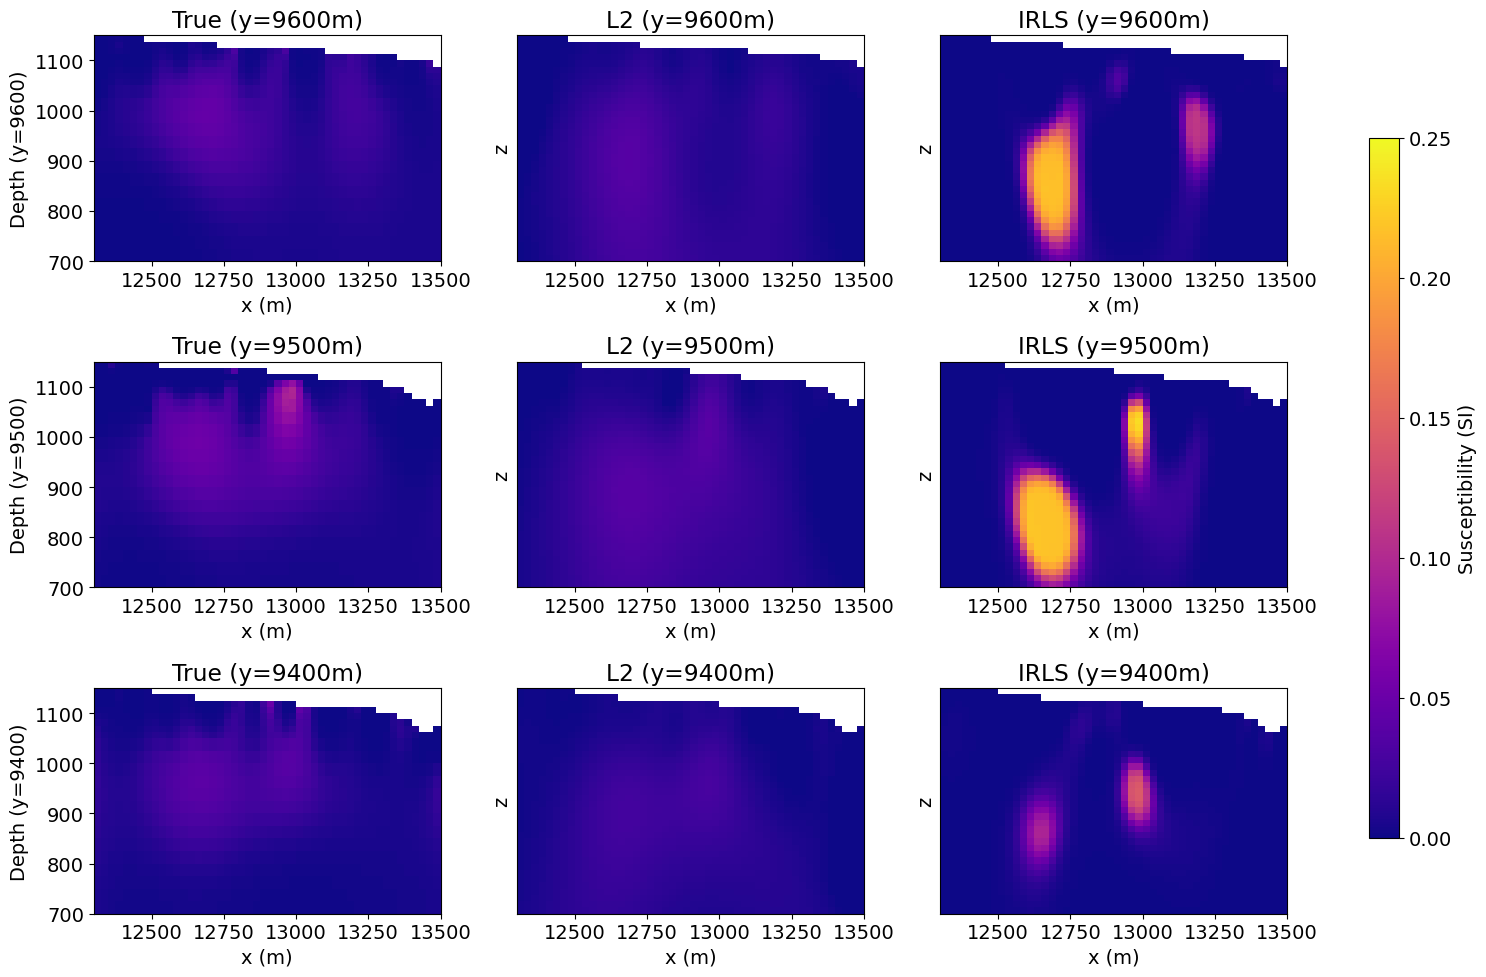

In [34]:
slice_ys = [9600, 9500, 9400]

models = [true_full, l2_full, irls_full]
titles = ["True", "L2", "IRLS"]

fig, axes = plt.subplots(len(slice_ys), 3, figsize=(15, 10))

# global color scale (important)

vmin = 0
vmax = 0.25
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

for i, y_val in enumerate(slice_ys):
    ind = y_to_index(y_val)

    for j, (model, title) in enumerate(zip(models, titles)):
        ax = axes[i, j]

        tensor_mesh.plot_slice(
            model,
            normal="Y",
            ind=ind,
            ax=ax,
            grid=False,
            pcolor_opts={
                "cmap": mpl.cm.plasma,
                "norm": norm
            },
        )

        # remove padding visually
        ax.set_xlim([x0, x0 + nx * dx])
        ax.set_ylim([z0 - nz * dz, z0])
        

        
        ax.set_title(title+f' (y={slice_ys[i]}m)')

        ax.set_xlabel("x (m)")
        if j == 0:
            ax.set_ylabel(f"Depth (y={y_val})")
        else:
            ax.set_yticks([])

# shared colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
mpl.colorbar.ColorbarBase(
    cbar_ax,
    norm=norm,
    cmap=mpl.cm.plasma,
).set_label("Susceptibility (SI)")

plt.tight_layout(rect=[0, 0, 0.9, 1])
init_utils.save_figure('IRLSs10_sm10_l2_true_comparison')
plt.show()


/var/folders/3d/yf36xnp966v6l9x5ngg5879w0000gn/T/ipykernel_14844/529310339.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


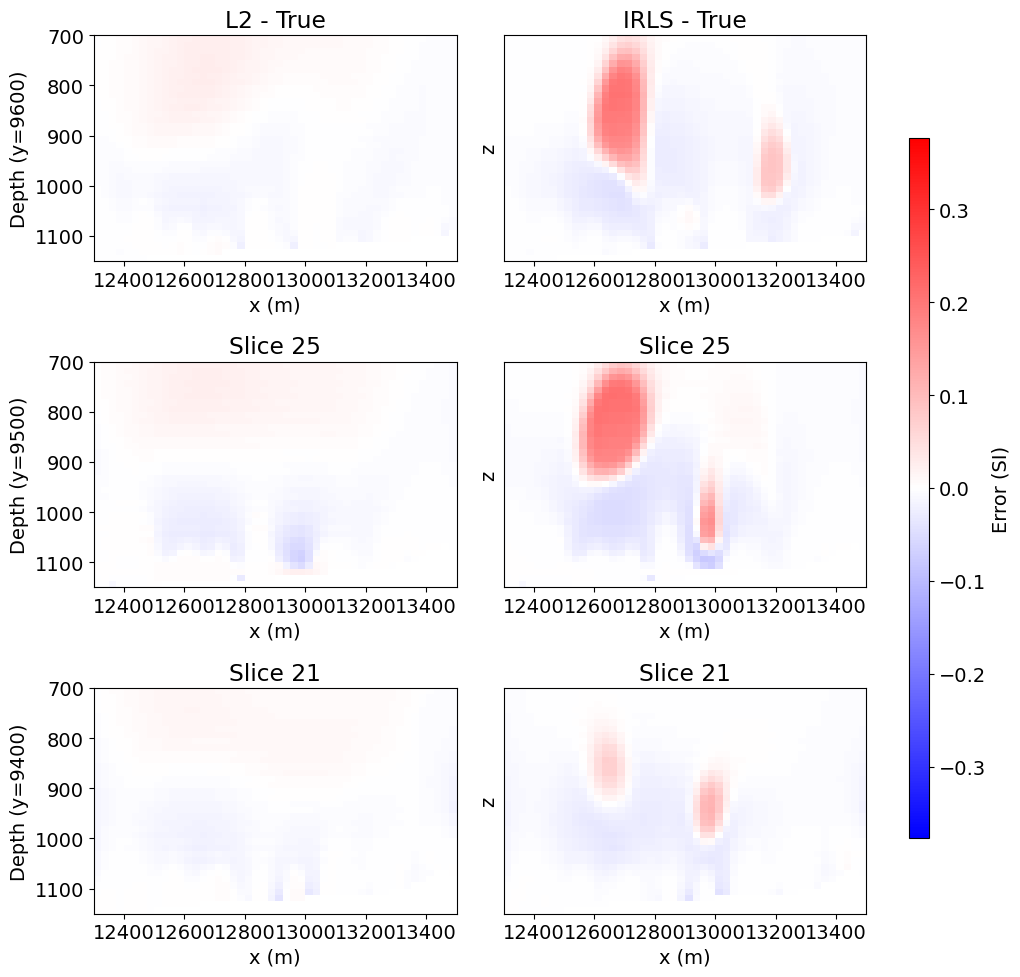

In [35]:
diff_l2   = L2_chosen - true_active
diff_irls = IRLS_chosen - true_active

diff_models = [
    tensor_plotting_map * diff_l2,
    tensor_plotting_map * diff_irls
]

diff_titles = ["L2 - True", "IRLS - True"]

fig, axes = plt.subplots(len(slice_ys), 2, figsize=(10, 10))

vmax = max(
    np.nanmax(np.abs(diff_l2)),
    np.nanmax(np.abs(diff_irls))
)
norm = mpl.colors.Normalize(vmin=-vmax, vmax=vmax)

for i, y_val in enumerate(slice_ys):
    ind = y_to_index(y_val)

    for j, (model, title) in enumerate(zip(diff_models, diff_titles)):
        ax = axes[i, j]

        tensor_mesh.plot_slice(
            model,
            normal="Y",
            ind=ind,
            ax=ax,
            grid=False,
            pcolor_opts={
                "cmap": "bwr",
                "norm": norm
            },
        )

        ax.set_xlim([x0, x0 + nx * dx])
        ax.set_ylim([z0 - nz * dz, z0])
        ax.invert_yaxis()

        if i == 0:
            ax.set_title(title)

        ax.set_xlabel("x (m)")
        if j == 0:
            ax.set_ylabel(f"Depth (y={y_val})")
        else:
            ax.set_yticks([])

# shared colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
mpl.colorbar.ColorbarBase(
    cbar_ax,
    norm=norm,
    cmap="bwr",
).set_label("Error (SI)")

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()